In [38]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,confusion_matrix,
                             accuracy_score,precision_score,recall_score,f1_score,
                            roc_curve,auc,matthews_corrcoef, 
                             cohen_kappa_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from xgboost import XGBClassifier
import pandas as pd
import warnings



BASE_DATA_DIR = 'dataset'
class_names = ['Benign', 'Malignant']

warnings.filterwarnings("ignore")

In [39]:
# Function to Extract Features from a Single Contour

def get_single_cell_features(img_gray, cnt):
    
    # 1. Morphological Features
    nucleus_area = cv2.contourArea(cnt)
    
    # Filter out very small contours
    if nucleus_area < 50:  
        return None
        
    nucleus_perimeter = cv2.arcLength(cnt, True)
    
    # Bounding box for approximate cell area 
    x, y, w, h = cv2.boundingRect(cnt)
    total_cell_area_proxy = w * h 
    
    # Nucleus to Cytoplasm Ratio (N/C Ratio)
    nc_ratio = nucleus_area / total_cell_area_proxy if total_cell_area_proxy > 0 else 0
    
    # Circularity 
    circularity = (4 * np.pi * nucleus_area) / (nucleus_perimeter**2) if nucleus_perimeter > 0 else 0
    
    # 2. Texture Features (GLCM) on the nucleus region
    cropped_nucleus = img_gray[y:y+h, x:x+w]
    
    if cropped_nucleus.size == 0 or np.all(cropped_nucleus == 0):
        return None
    
    # Reduce intensity levels to 64 for GLCM for stability and computation speed
    cropped_nucleus_small = (cropped_nucleus / 4).astype(np.uint8) 
    

    # Create GLCM (gray level co-occurence matrix
    glcm = graycomatrix(cropped_nucleus_small, 
                        distances=[1], 
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], 
                        levels=64, 
                        symmetric=True, 
                        normed=True)
    
    # Extract mean GLCM properties across all angles
    contrast = np.mean(graycoprops(glcm, 'contrast'))
    energy = np.mean(graycoprops(glcm, 'energy'))
    correlation = np.mean(graycoprops(glcm, 'correlation'))
    homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))
    # dissimilarity = np.mean(graycoprops(glcm, 'dissimilarity'))
    # entropy = np.mean(graycoprops(glcm,'entropy'))

    # Advanced GLCM (Entropy & Shade)
    i, j = np.ogrid[:256, :256]
    entropy = np.mean([-np.sum(glcm[:,:,0,a] * np.log2(glcm[:,:,0,a] + (glcm[:,:,0,a]==0))) for a in range(4)])
    

    
    # 3. Compile Features
    features = [
        nc_ratio,
        nucleus_area,
        nucleus_perimeter,
        circularity,
        contrast,
        energy,
        correlation,
        homogeneity,
        # dissimilarity,
        # entropy
    ]
    # labels = np.array(label_list) # 0 for Benign, 1 for Malignant
    return features


In [40]:
def create_superpixel_means(image_rgb, labels):
        """Average color for each superpixel"""
        superpixel_means = np.zeros_like(image_rgb)
        unique_labels = np.unique(labels)
        
        for label in unique_labels:
            mask = (labels == label)
            if np.any(mask):
                mean_color = np.mean(image_rgb[mask], axis=0).astype(np.uint8)
                superpixel_means[mask] = mean_color
        
        return superpixel_means


In [41]:
#Main Feature Extraction Function (Handles multiple cells per image)
def extract_features_from_image(image_path):
    all_cell_features = []
    try:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            return all_cell_features    

        # slic = cv2.ximgproc.createSuperpixelSLIC(img_bgr, region_size=15, ruler=10.0)
        # slic.iterate(10)
        # mask_slic = slic.getLabelContourMask()
        # mask_inv_slic = cv2.bitwise_not(mask_slic)
        # image_slic = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_inv_slic)

        # # Get labels for SUPERPIXEL MEANS
        # labels = slic.getLabels()
        # superpixel_means_bgr = create_superpixel_means(img_bgr, labels)
        
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        #Segmentation
        # Otsu's thresholding to get a  binary mask of all nucleus basically converting image of nucleus to white pixel
        #and remaining others are dark or black pixel
        
        _, thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
        #Find ALL Contours (for cells) , each image cells has more than one contour because its multi cell image
        contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            return all_cell_features
            
        #Iterate and extract features for each contour
        for cnt in contours:
            features = get_single_cell_features(img_gray, cnt)
            if features is not None:
                all_cell_features.append(features)
                    
        return all_cell_features

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return all_cell_features


In [42]:
#Loads images from dataset folder and calls extract features  function to get all cell features
def load_and_extract_data(base_dir):
    features_list = []
    labels_list = []
    
    class_mapping = {'benign': 0, 'malignant': 1}
    
    for class_name, label in class_mapping.items():
        folder_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(folder_path):
            continue
            
        print(f"Processing images in: {class_name} ({label})")
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(folder_path, filename)
                
                
                # Extract features for all cells in this image
                cells_features = extract_features_from_image(image_path)
                
                # Assign the images label to each cell features
                for features in cells_features:
                    features_list.append(features)
                    labels_list.append(label)
    # Create DataFrame with exact column names from your feature list
    columns = ['nc_ratio', 'nucleus_area', 'nucleus_perimeter', 'circularity', 
               'contrast', 'energy', 'correlation', 'homogeneity']
    
    # Convert to pandas DataFrame (handles both single and multi-cell images)
    X_df = pd.DataFrame(features_list, columns=columns)
    y_df = pd.Series(labels_list, name='label')
    
    # print(f"Dataset shape: {X_df.shape}")
    # print(f"Features: {list(X_df.columns)}")
    # print(f"Label distribution:\n{y_df.value_counts()}")
    # print(X_df)
    return X_df, y_df ,X_df


In [43]:
X,y,df = load_and_extract_data(BASE_DATA_DIR)
df

Processing images in: benign (0)
Processing images in: malignant (1)


,nc_ratio,nucleus_area,nucleus_perimeter,circularity,contrast,energy,correlation,homogeneity
0,0.714286,160.0,51.313708,0.763595,22.620524,0.091925,0.908760,0.312976
1,0.572215,935.0,145.195958,0.557330,18.571093,0.164187,0.945874,0.473381
2,0.695370,375.5,78.183766,0.771945,34.766024,0.137196,0.866033,0.431947
3,0.461830,913.5,160.124890,0.447714,26.476412,0.196514,0.948197,0.480416
4,0.533875,394.0,135.740114,0.268714,34.223912,0.129990,0.835740,0.419122
...,...,...,...,...,...,...,...,...
32371,0.779167,187.0,53.313708,0.826749,5.840759,0.134716,0.814844,0.438485
32372,0.347594,65.0,52.284271,0.298800,4.901395,0.126286,0.817101,0.464001
32373,0.713542,205.5,56.384776,0.812265,4.991680,0.161990,0.868558,0.507065
32374,0.415618,2113.0,368.534051,0.195503,6.837360,0.127385,0.959264,0.550253


In [44]:
X

,nc_ratio,nucleus_area,nucleus_perimeter,circularity,contrast,energy,correlation,homogeneity
0,0.714286,160.0,51.313708,0.763595,22.620524,0.091925,0.908760,0.312976
1,0.572215,935.0,145.195958,0.557330,18.571093,0.164187,0.945874,0.473381
2,0.695370,375.5,78.183766,0.771945,34.766024,0.137196,0.866033,0.431947
3,0.461830,913.5,160.124890,0.447714,26.476412,0.196514,0.948197,0.480416
4,0.533875,394.0,135.740114,0.268714,34.223912,0.129990,0.835740,0.419122
...,...,...,...,...,...,...,...,...
32371,0.779167,187.0,53.313708,0.826749,5.840759,0.134716,0.814844,0.438485
32372,0.347594,65.0,52.284271,0.298800,4.901395,0.126286,0.817101,0.464001
32373,0.713542,205.5,56.384776,0.812265,4.991680,0.161990,0.868558,0.507065
32374,0.415618,2113.0,368.534051,0.195503,6.837360,0.127385,0.959264,0.550253


In [45]:
X.to_csv('blood_cell_data__image_features.csv',index=False)

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)



In [47]:
# #plots confusion matrix for each ML classifier and saves it
# def plotting_confusion_matrix(conf_matrix):
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(conf_matrix, 
#                 annot=True, 
#                 fmt='d', 
#                 cmap='Blues', 
#                 xticklabels=class_names, 
#                 yticklabels=class_names)
    
#     plt.title('Confusion Matrix for ALL Cell Classification')
#     plt.ylabel('Actual Label (True)')
#     plt.xlabel('Predicted Label')
#     plt.show()
#     return
    

In [48]:
'''function to plot ROC AUC curves and confusion matrix for both class benign and malignant'''

def plot_roc_auc_curves(model, X_test, y_test,y_pred,cm, model_name):
    # 1. Generate Predictions and Probabilities
    # y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1] # Probability of being Malignant
    
    # 2. Calculate Advanced Metrics
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    # 3. Plotting the ROC Curve
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,7))

    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    ax1.plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax1.set_title(f'ROC Curve: {model_name}')
    ax1.set_xlabel('False Positive Rate (1 - Specificity)')
    ax1.set_ylabel('True Positive Rate (Sensitivity)')
    ax1.legend(loc="lower right")
    ax1.grid(alpha=0.3)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    ax2.set_title(f'Confusion Matrix: {model_name}')
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('Actual Label')
    ax2.set_xticklabels(['Benign', 'Malignant'])
    ax2.set_yticklabels(['Benign', 'Malignant'])
    
    # 4. Print Summary Table
    # print(f"\n{'='*20} {model_name.upper()} REPORT {'='*20}")
    print(f"MCC Score:   {mcc:.4f}")
    print(f"Kappa Score: {kappa:.4f}")
    print(f"AUC-ROC:     {roc_auc:.4f}")
    print(f"{'='*50}\n")
        
    plt.tight_layout()
    plt.show()
    
    

Accuracy : 0.7980

Classification Report (0: Benign, 1: Malignant):
              precision    recall  f1-score   support

      Benign       0.81      0.73      0.77      2960
   Malignant       0.79      0.86      0.82      3516

    accuracy                           0.80      6476
   macro avg       0.80      0.79      0.79      6476
weighted avg       0.80      0.80      0.80      6476

Precision Score :  0.7900683131897005
Recall Score :  0.8552332195676906
F1-score :  0.8213602840753892

Confusion Matrix (Actual Rows, Predicted Columns):

 Plotting ROC AUC Curve and Confusion Matrix
MCC Score:   0.5923
Kappa Score: 0.5899
AUC-ROC:     0.5000



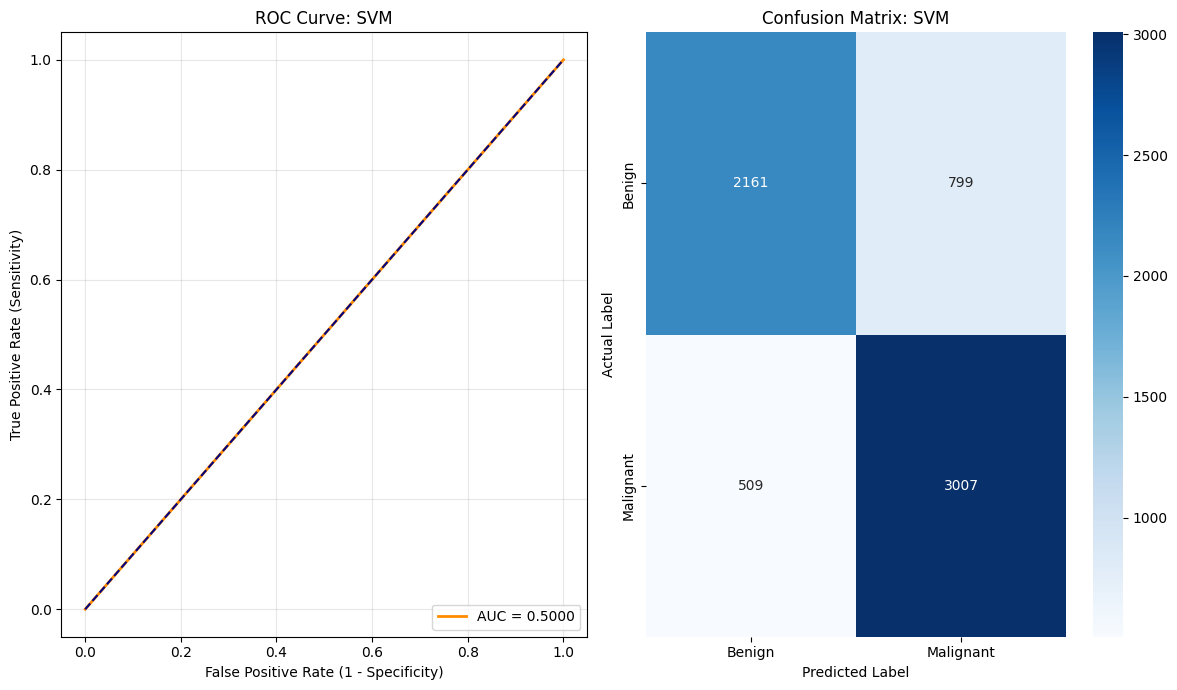

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf',probability=True,C=10,gamma='scale',random_state=42)
svm_model.fit(X_train_scaled,y_train)

y_pred = svm_model.predict(X_test_scaled)

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print("\nClassification Report (0: Benign, 1: Malignant):")
print(classification_report(y_test, y_pred, target_names=class_names))
print('Precision Score : ',precision_score(y_test,y_pred))
print('Recall Score : ',recall_score(y_test, y_pred))
print('F1-score : ',f1_score(y_test, y_pred))

print("\nConfusion Matrix (Actual Rows, Predicted Columns):")
cm = confusion_matrix(y_test, y_pred)

print("\n Plotting ROC AUC Curve and Confusion Matrix")
plot_roc_auc_curves(svm_model, X_test, y_test, y_pred,cm ,'SVM')

Accuracy : 0.7637

Classification Report (0: Benign, 1: Malignant):
              precision    recall  f1-score   support

      Benign       0.77      0.69      0.73      2960
   Malignant       0.76      0.82      0.79      3516

    accuracy                           0.76      6476
   macro avg       0.76      0.76      0.76      6476
weighted avg       0.76      0.76      0.76      6476

Precision Score :  0.760766806722689
Recall Score :  0.823947667804323
F1-score :  0.7910977607864554

** Plotting ROC AUC Curve and Confusion Matrix. **
MCC Score:   0.5224
Kappa Score: 0.5202
AUC-ROC:     0.8201



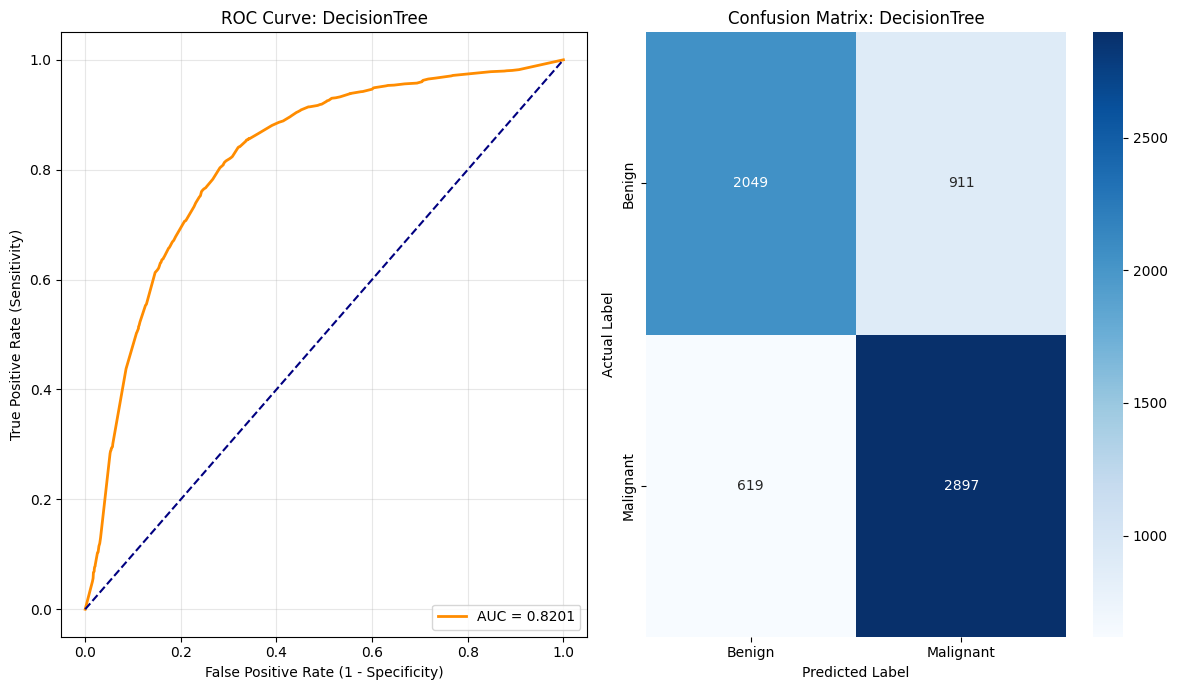

In [50]:
#Decision Trees

dtree_model  = DecisionTreeClassifier(max_depth=10,min_samples_split=5,min_samples_leaf=2,random_state=42)
dtree_model.fit(X_train,y_train)

#evaluation
y_pred = dtree_model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print("\nClassification Report (0: Benign, 1: Malignant):")
print(classification_report(y_test, y_pred, target_names=class_names))
print('Precision Score : ',precision_score(y_test,y_pred))
print('Recall Score : ',recall_score(y_test, y_pred))
print('F1-score : ',f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\n** Plotting ROC AUC Curve and Confusion Matrix. **")
plot_roc_auc_curves(dtree_model, X_test, y_test,y_pred,cm, 'DecisionTree')

Accuracy : 0.5865

Classification Report (0: Benign, 1: Malignant):
              precision    recall  f1-score   support

      Benign       0.66      0.19      0.30      2960
   Malignant       0.57      0.92      0.71      3516

    accuracy                           0.59      6476
   macro avg       0.62      0.56      0.50      6476
weighted avg       0.61      0.59      0.52      6476

Precision Score :  0.574768022840828
Recall Score :  0.9160978384527872
F1-score :  0.706359649122807

 Plotting ROC AUC Curve and Confusion Matrix
MCC Score:   0.1620
Kappa Score: 0.1176
AUC-ROC:     0.7290



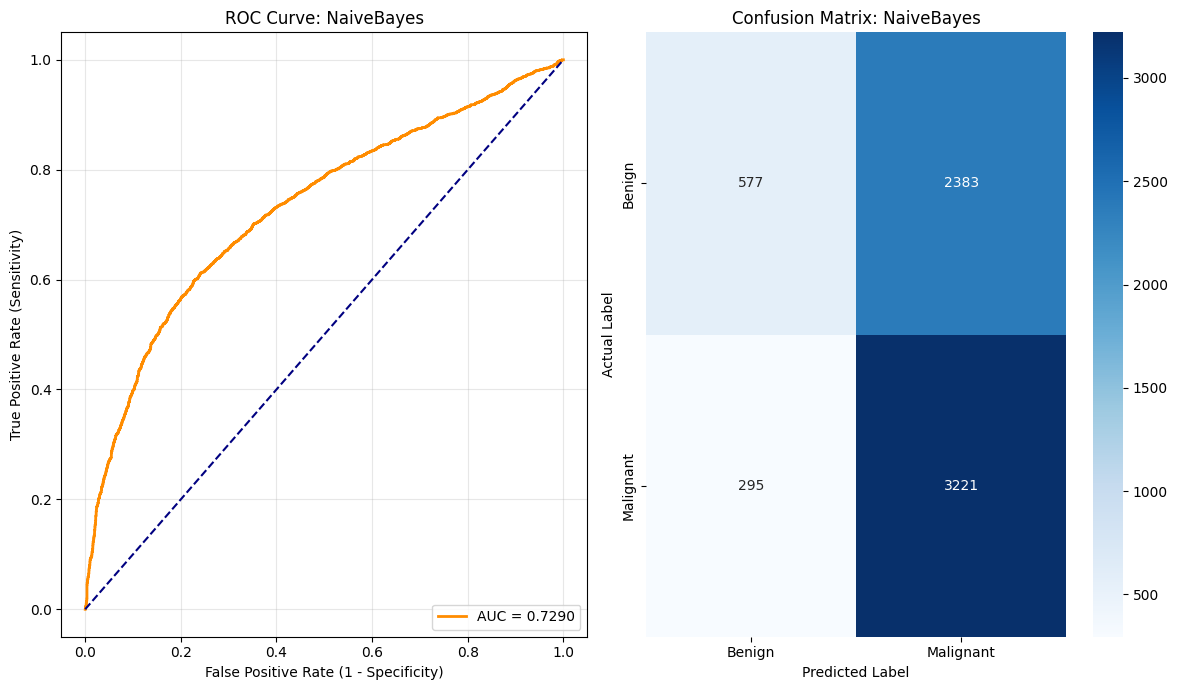

In [51]:
#guassian naive bayes

nb_model = GaussianNB()
nb_model.fit(X_train,y_train)

y_pred = nb_model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print("\nClassification Report (0: Benign, 1: Malignant):")
print(classification_report(y_test, y_pred, target_names=class_names))
print('Precision Score : ',precision_score(y_test,y_pred))
print('Recall Score : ',recall_score(y_test, y_pred))
print('F1-score : ',f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\n Plotting ROC AUC Curve and Confusion Matrix")
plot_roc_auc_curves(nb_model, X_test, y_test,y_pred,cm, 'NaiveBayes')

Accuracy : 0.7827

Classification Report (0: Benign, 1: Malignant):
              precision    recall  f1-score   support

      Benign       0.79      0.71      0.75      2960
   Malignant       0.77      0.85      0.81      3516

    accuracy                           0.78      6476
   macro avg       0.78      0.78      0.78      6476
weighted avg       0.78      0.78      0.78      6476

Precision Score :  0.774680906486064
Recall Score :  0.8458475540386803
F1-score :  0.8087015635622026

** Plotting ROC AUC Curve and Confusion Matrix. **
MCC Score:   0.5613
Kappa Score: 0.5584
AUC-ROC:     0.8580



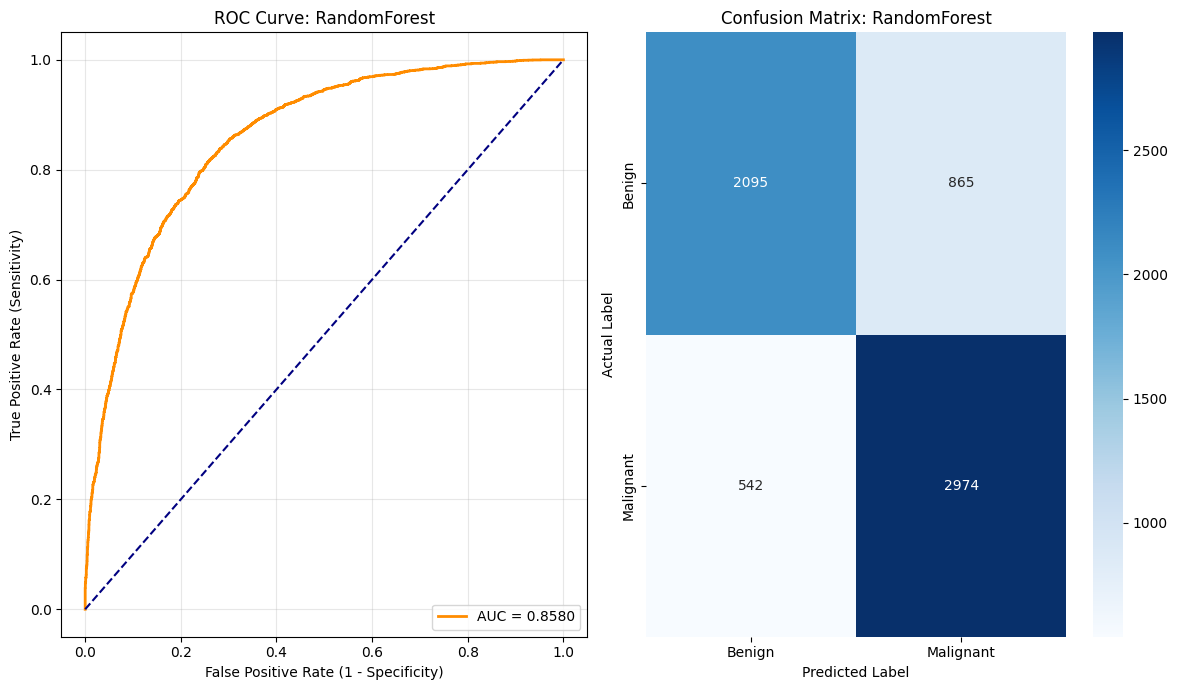

In [52]:
#Random Forest

rf_model  = RandomForestClassifier(n_estimators=100, max_depth=10,random_state=42)
rf_model.fit(X_train,y_train)

y_pred = rf_model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print("\nClassification Report (0: Benign, 1: Malignant):")
print(classification_report(y_test, y_pred, target_names=class_names))
print('Precision Score : ',precision_score(y_test,y_pred))
print('Recall Score : ',recall_score(y_test, y_pred))
print('F1-score : ',f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\n** Plotting ROC AUC Curve and Confusion Matrix. **")
plot_roc_auc_curves(rf_model, X_test, y_test,y_pred,cm, 'RandomForest')

Accuracy : 0.7920

Classification Report (0: Benign, 1: Malignant):
              precision    recall  f1-score   support

      Benign       0.79      0.75      0.77      2960
   Malignant       0.80      0.83      0.81      3516

    accuracy                           0.79      6476
   macro avg       0.79      0.79      0.79      6476
weighted avg       0.79      0.79      0.79      6476

Precision Score :  0.7955846279640229
Recall Score :  0.8302047781569966
F1-score :  0.812526096033403

** Plotting ROC AUC Curve and Confusion Matrix. **
MCC Score:   0.5799
Kappa Score: 0.5792
AUC-ROC:     0.8720



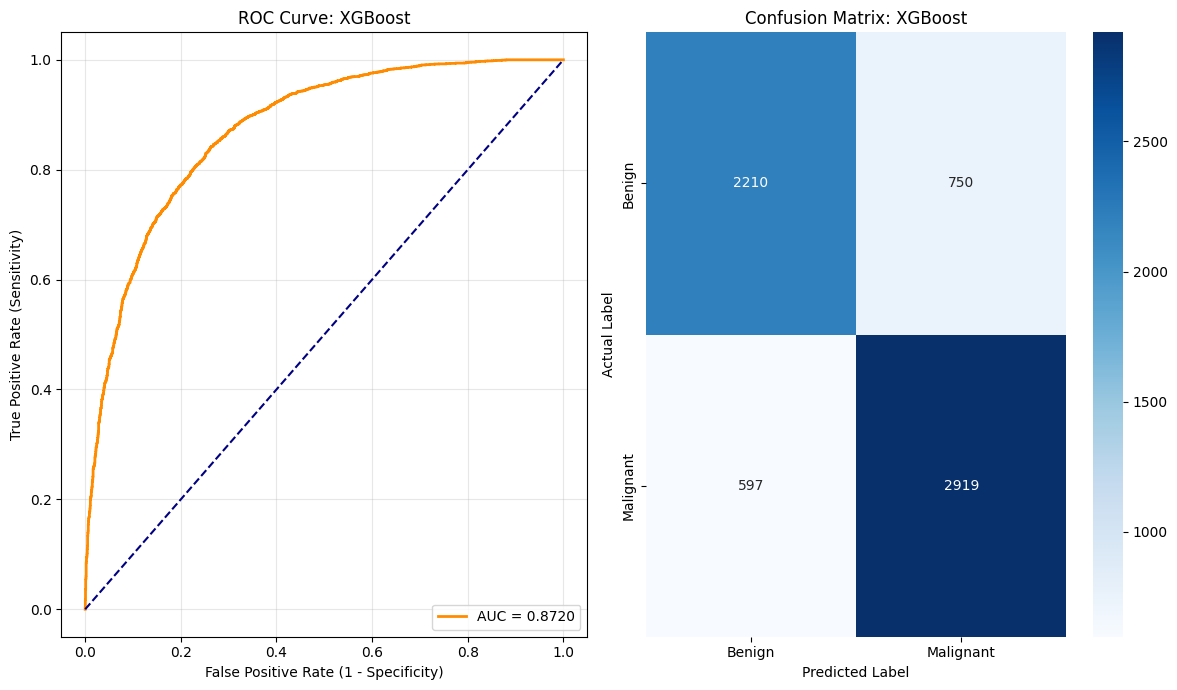

In [53]:
#XGBoost Model

xgboost_model = XGBClassifier(
        n_estimators=100,      # Number of trees
        max_depth=7,           # Tree depth
        learning_rate=0.2,     # Step size
        random_state=42
    )
xgboost_model.fit(X_train,y_train)

y_pred = xgboost_model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print("\nClassification Report (0: Benign, 1: Malignant):")
print(classification_report(y_test, y_pred, target_names=class_names))
print('Precision Score : ',precision_score(y_test,y_pred))
print('Recall Score : ',recall_score(y_test, y_pred))
print('F1-score : ',f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\n** Plotting ROC AUC Curve and Confusion Matrix. **")
plot_roc_auc_curves(xgboost_model, X_test, y_test,y_pred,cm, 'XGBoost')

Accuracy : 0.7861

Classification Report (0: Benign, 1: Malignant):
              precision    recall  f1-score   support

      Benign       0.78      0.74      0.76      2960
   Malignant       0.79      0.82      0.81      3516

    accuracy                           0.79      6476
   macro avg       0.79      0.78      0.78      6476
weighted avg       0.79      0.79      0.79      6476

Precision Score :  0.7921579380312586
Recall Score :  0.8216723549488054
F1-score :  0.8066452603657686

** Plotting ROC AUC Curve and Confusion Matrix. **
MCC Score:   0.5681
Kappa Score: 0.5676
AUC-ROC:     0.8625



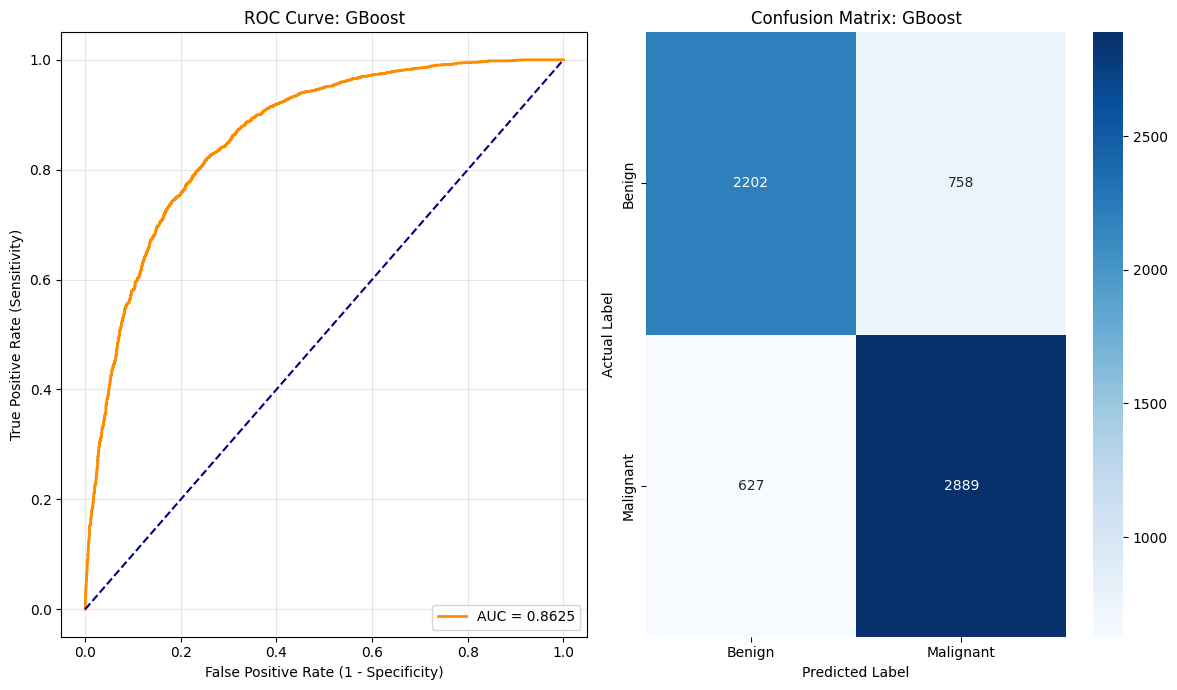

In [54]:
#Gradient Boosting

gboost_model = GradientBoostingClassifier(
                n_estimators=100,    
                max_depth=10,         
                learning_rate=0.2,
                random_state=42)

gboost_model.fit(X_train,y_train)

y_pred = gboost_model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print("\nClassification Report (0: Benign, 1: Malignant):")
print(classification_report(y_test, y_pred, target_names=class_names))
print('Precision Score : ',precision_score(y_test,y_pred))
print('Recall Score : ',recall_score(y_test, y_pred))
print('F1-score : ',f1_score(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

print("\n** Plotting ROC AUC Curve and Confusion Matrix. **")
plot_roc_auc_curves(gboost_model, X_test, y_test,y_pred,cm, 'GBoost')

In [55]:
# from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
# import matplotlib.pyplot as plt

# # 1. Get Probabilities for both classes
# # column 0 is Benign, column 1 is Malignant
# y_probs = gboost_model.predict_proba(X_test)

# # 2. Calculate Metrics for Malignant (Class 1)
# fpr_m, tpr_m, _ = roc_curve(y_test, y_probs[:, 1], pos_label=1)
# roc_auc_m = auc(fpr_m, tpr_m)
# prec_m = precision_score(y_test, y_pred, pos_label=1)
# rec_m = recall_score(y_test, y_pred, pos_label=1)

# # 3. Calculate Metrics for Benign (Class 0)
# fpr_b, tpr_b, _ = roc_curve(y_test, y_probs[:, 0], pos_label=0)
# roc_auc_b = auc(fpr_b, tpr_b)
# prec_b = precision_score(y_test, y_pred, pos_label=0)
# rec_b = recall_score(y_test, y_pred, pos_label=0) # This is effectively Specificity

# # 4. Create the Subplots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# # Subplot 1: Malignant ROC
# ax1.plot(fpr_m, tpr_m, color='red', lw=2, label=f'Malignant ROC (AUC = {roc_auc_m:.4f})')
# ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
# ax1.set_title('ROC Curve: Malignant Class (Sensitivity)')
# ax1.set_xlabel('False Positive Rate')
# ax1.set_ylabel('True Positive Rate')
# ax1.legend(loc="lower right")
# ax1.grid(alpha=0.3)

# # Subplot 2: Benign ROC
# ax2.plot(fpr_b, tpr_b, color='blue', lw=2, label=f'Benign ROC (AUC = {roc_auc_b:.4f})')
# ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
# ax2.set_title('ROC Curve: Benign Class (Specificity)')
# ax2.set_xlabel('False Positive Rate (Malignant as False)')
# ax2.set_ylabel('True Positive Rate (Benign Recall)')
# ax2.legend(loc="lower right")
# ax2.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Print Comparison Table
# print(f"{'Class':<12} | {'Precision':<10} | {'Recall':<10} | {'AUC':<10}")
# print("-" * 50)
# print(f"{'Benign':<12} | {prec_b:<10.4f} | {rec_b:<10.4f} | {roc_auc_b:<10.4f}")
# print(f"{'Malignant':<12} | {prec_m:<10.4f} | {rec_m:<10.4f} | {roc_auc_m:<10.4f}")